Interior points : 1444
Boundary points : 400
Total unknown: 576


Time taken: 0.23 s

Residual after update = 2.88e-09

RMS error = 8.05e-12, Linf error = 3.05e-11

Max BC error  = 8.08e-28
Mean BC error = 2.02e-30


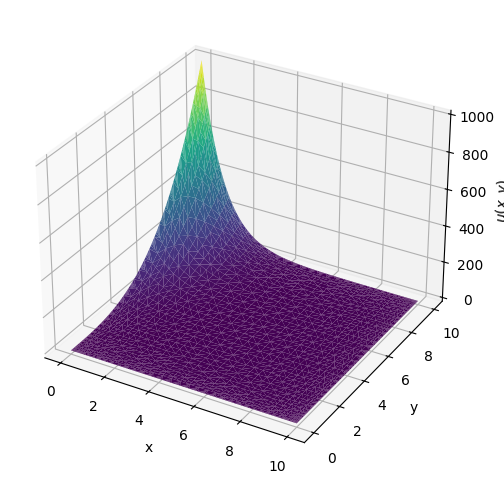

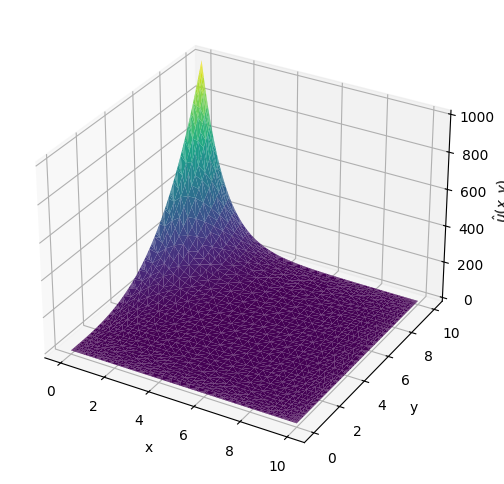

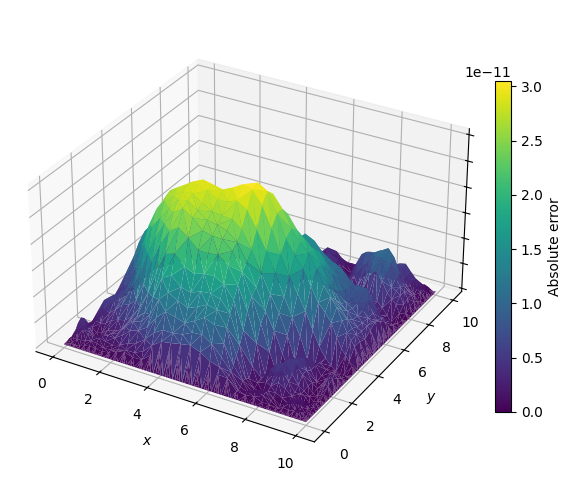

In [1]:
import numpy as np
from numpy.polynomial.legendre import legval, legder

import matplotlib.pyplot as plt
import matplotlib.tri as mtri

from scipy.linalg import lu_factor, lu_solve
import time


# ==========================================================
# Exact Solution and Right-Hand Side
# ==========================================================
def u_exact(x, y):
    return np.exp(-x) * (x + y**3)


def f_rhs(x, y):
    return np.exp(-x) * (x - 2 + y**3 + 6*y)


# ==========================================================
# Load Domain Points
# ==========================================================
interior_pts = np.load("data/square_interior_points.npy")
boundary_pts = np.load("data/square_boundary_points.npy")

print("Interior points :", interior_pts.shape[0])
print("Boundary points :", boundary_pts.shape[0])


# ==========================================================
# Basis Parameters
# ==========================================================
N_basis = 24

print("Total unknown:", N_basis**2)


# ==========================================================
# Separate Coordinates
# ==========================================================
xi_int, yi_int = interior_pts[:, 0], interior_pts[:, 1]
xi_b, yi_b     = boundary_pts[:, 0], boundary_pts[:, 1]

X_all = np.concatenate([xi_int, xi_b])
Y_all = np.concatenate([yi_int, yi_b])

# ==========================================================
# Shifted Legendre Basis on [0,10] × [0,10]
# ==========================================================
def leg_shifted(n, x):

    # Map x from [0,10] → [-1,1]
    x_hat = x / 5 - 1.0

    coeffs = [0] * n + [1]

    return legval(x_hat, coeffs)


# ==========================================================
# 2D Tensor Product Legendre Basis Matrix
# ==========================================================
def legendre_matrix_2d(x, y, N):

    cols = []

    for i in range(N):

        Px = leg_shifted(i, x)

        for j in range(N):

            Py = leg_shifted(j, y)

            cols.append(Px * Py)

    return np.vstack(cols).T


# ==========================================================
# Second Derivative Matrices
# ==========================================================
def legendre_derivative_matrices_2d(x, y, N):

    dxx_cols = []
    dyy_cols = []

    # ======================================================
    # Coordinate mapping:
    # x_hat = x/5 - 1
    # Chain-rule scaling:
    # d²/dx² = (1/25)d²/dx_hat²
    # ======================================================
    x_hat = (x / 5) - 1.0
    y_hat = (y / 5) - 1.0

    scale = 1 / 25

    for i in range(N):

        ci = [0] * i + [1]

        d2ci = legder(legder(ci))

        Px   = legval(x_hat, ci)
        d2Px = scale * legval(x_hat, d2ci)

        for j in range(N):

            cj = [0] * j + [1]

            d2cj = legder(legder(cj))

            Py   = legval(y_hat, cj)
            d2Py = scale * legval(y_hat, d2cj)

            dxx_cols.append(d2Px * Py)
            dyy_cols.append(Px * d2Py)

    return np.vstack(dxx_cols).T, np.vstack(dyy_cols).T


# ==========================================================
# Assemble Basis Matrices
# ==========================================================
P_int = legendre_matrix_2d(xi_int, yi_int, N_basis)
P_b   = legendre_matrix_2d(xi_b, yi_b, N_basis)

dxx_int, dyy_int = legendre_derivative_matrices_2d(
    xi_int,
    yi_int,
    N_basis
)


# ==========================================================
# RHS and Boundary Data
# ==========================================================
RHS_int   = f_rhs(xi_int, yi_int)
U_b_exact = u_exact(xi_b, yi_b)

start = time.time()

# ==========================================================
# Gaussian RBF Matrix
# ==========================================================
def rbf_matrix(x, y, cx, cy, lam):

    dx = x[:, None] - cx[None, :]
    dy = y[:, None] - cy[None, :]

    return np.exp(-lam * (dx**2 + dy**2))


lam = 63.0


# ==========================================================
# Boundary System
# ==========================================================
cx, cy = xi_b.copy(), yi_b.copy()

A_bc = rbf_matrix(xi_b, yi_b, cx, cy, lam)

LU, piv = lu_factor(A_bc)

print("")


# ==========================================================
# Interior RBF Quantities
# ==========================================================
dx = xi_int[:, None] - cx[None, :]
dy = yi_int[:, None] - cy[None, :]

r2 = dx**2 + dy**2

Phi = np.exp(-lam * r2)

Phi_xx = (4 * lam**2 * dx**2 - 2 * lam) * Phi
Phi_yy = (4 * lam**2 * dy**2 - 2 * lam) * Phi


# ==========================================================
# Direct Reduced System Solve
# ==========================================================

AinvPb = lu_solve(
    (LU, piv),
    P_b
)

AinvGb = lu_solve(
    (LU, piv),
    U_b_exact
)

J_beta = (
    dxx_int
    + dyy_int
    - Phi_xx @ AinvPb
    - Phi_yy @ AinvPb
)

rhs_red = (
    RHS_int
    - Phi_xx @ AinvGb
    - Phi_yy @ AinvGb
)

beta = np.linalg.lstsq(
    J_beta,
    rhs_red,
    rcond=None
)[0]

# ==========================================================
# Final q Using Updated beta
# ==========================================================
u_b_pred = P_b @ beta

q = lu_solve(
    (LU, piv),
    U_b_exact - u_b_pred
)


# ==========================================================
# Final Solution Evaluation
# ==========================================================
Phi_all = rbf_matrix(
    X_all,
    Y_all,
    cx,
    cy,
    lam
)

P_all = np.vstack([P_int, P_b])

U_pred_all = P_all @ beta + Phi_all @ q

U_exact_all = u_exact(X_all, Y_all)

end = time.time()

print("")
print("Time taken:", np.round((end - start), 2), "s")
print("")


# ==========================================================
# Residual and Error
# ==========================================================
pde_res = np.linalg.norm(
    (dxx_int @ beta + Phi_xx @ q)
    + (dyy_int @ beta + Phi_yy @ q)
    - RHS_int
)

print(f"Residual after update = {pde_res:.2e}")

abs_error= np.abs(U_pred_all - U_exact_all)

print("")

print(
    f"RMS error = "
    f"{np.sqrt(np.mean(abs_error**2)):.2e}, "
    f"Linf error = "
    f"{np.max(abs_error):.2e}"
)


# ==========================================================
# Boundary Condition Verification
# ==========================================================
psi_boundary = u_b_pred + A_bc @ q

dirichlet_error = np.abs(
    psi_boundary - U_b_exact
)

print("")

print(f"Max BC error  = {np.max(dirichlet_error):.2e}")
print(f"Mean BC error = {np.mean(dirichlet_error):.2e}")


# ==========================================================
# Triangulation
# ==========================================================
triang = mtri.Triangulation(X_all, Y_all)


# ==========================================================
# Figure 1: Exact Solution
# ==========================================================
fig1 = plt.figure(figsize=(6, 6))

ax1 = fig1.add_subplot(
    111,
    projection='3d'
)

surf1 = ax1.plot_trisurf(
    triang,
    U_exact_all,
    cmap='viridis',
    vmin=0.0,
    vmax=U_exact_all.max()
)

ax1.set_title('')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel(r'$u(x,y)$')

plt.savefig(
    "fig1_exact.pdf",dpi=300,
    bbox_inches="tight",
    pad_inches=0.18
)


plt.show()


# ==========================================================
# Figure 2: Approximate Solution
# ==========================================================
vmin = 0.0
vmax = max(
    U_exact_all.max(),
    U_pred_all.max()
)

fig2 = plt.figure(figsize=(6, 6))

ax2 = fig2.add_subplot(
    111,
    projection='3d'
)

surf2 = ax2.plot_trisurf(
    triang,
    U_pred_all,
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)

ax2.set_title('')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel(r'$\hat{u}(x,y)$')

plt.savefig(
    "fig1_approx.pdf",
    dpi=300,
    bbox_inches="tight",pad_inches=0.18
)


plt.show()


# ==========================================================
# Error Surface plot 
# ==========================================================
vmin_after  = 0.0
vmax_after  = abs_error.max()

fig2 = plt.figure(figsize=(6,6))
ax2 = fig2.add_subplot(111, projection='3d')

surf2 = ax2.plot_trisurf(
    triang,
    abs_error,
    cmap='viridis',
    vmin=vmin_after,
    vmax=vmax_after
)

ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$y$")
ax2.set_zticklabels([])           # keep grid but hide z numbers
ax2.set_box_aspect((1,1,0.6))

cbar2 = fig2.colorbar(surf2, ax=ax2, shrink=0.58, pad=0.02)
cbar2.set_label("Absolute error")

plt.tight_layout()

plt.savefig("fig1d.pdf",dpi=300, bbox_inches="tight", pad_inches=0.15)


plt.show()
plt.close(fig2)